# Импортируем библиотеки и входные данные

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

import requests
import apimoex
import yfinance as yf
import vectorbt as vbt

In [2]:
money = 100000
start = datetime.datetime(2018, 1, 1)
finish = datetime.datetime(2018, 12, 31)
stop_loss = 0.05
fast_window = 30
slow_window = 90

*Загружаем данные по ценной бумаге*

In [3]:
with requests.Session() as session:
    data = apimoex.get_market_candles(session, 'SBER', interval=60, start=start, end=finish)
    df = pd.DataFrame(data)
    df.set_index(pd.to_datetime(df['begin']), inplace=True)
    df.drop(['begin'], axis=1, inplace=True)
stock = df[['open', 'close', 'high', 'low']]
stock.columns = ['Open', 'Close', 'High', 'Low']
display(stock.head())
display(stock.tail())
stock.info()

,Open,Close,High,Low
begin,,,,
2018-01-03 09:00:00,226.88,226.88,226.88,226.88
2018-01-03 10:00:00,226.88,228.52,230.00,226.35
2018-01-03 11:00:00,228.45,229.66,230.58,228.41
2018-01-03 12:00:00,229.65,229.90,230.00,229.00
2018-01-03 13:00:00,229.90,230.38,230.80,229.60


,Open,Close,High,Low
begin,,,,
2018-12-29 14:00:00,186.07,185.88,186.08,185.78
2018-12-29 15:00:00,185.88,185.70,185.95,185.70
2018-12-29 16:00:00,185.70,186.15,186.15,185.70
2018-12-29 17:00:00,186.15,186.02,186.35,186.00
2018-12-29 18:00:00,186.05,186.30,186.49,185.97


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2540 entries, 2018-01-03 09:00:00 to 2018-12-29 18:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2540 non-null   float64
 1   Close   2540 non-null   float64
 2   High    2540 non-null   float64
 3   Low     2540 non-null   float64
dtypes: float64(4)
memory usage: 99.2 KB


## Посмотрим на данные 

In [4]:
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly.graph_objs as go
init_notebook_mode(connected=True)

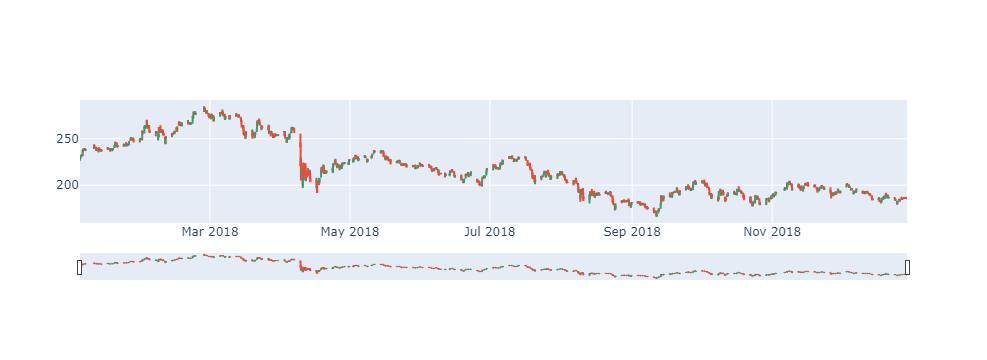

In [5]:
trace = go.Ohlc(x=stock.index,
                open=stock['Open'],
                high=stock['High'],
                low=stock['Low'],
                close=stock['Close'])

data = [trace]
iplot(data)

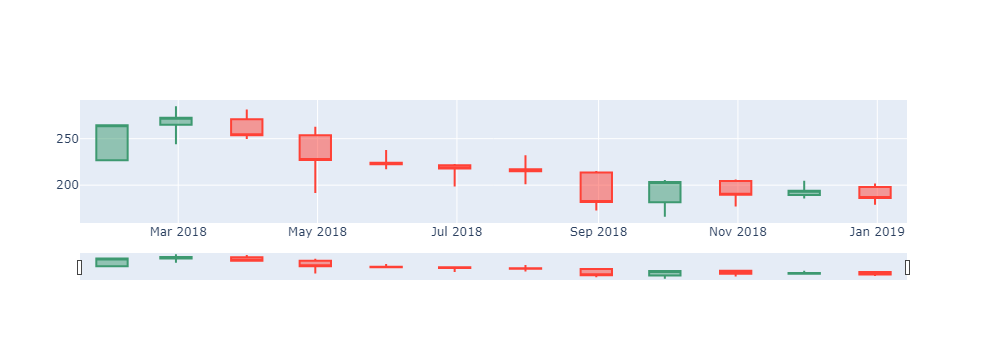

In [6]:
stock_month = stock.resample('M').agg({'Open':'first','Low':'min','High':'max','Close':'last'})
month = stock_month.index

trace2 = go.Candlestick(
                x=month, 
                open=stock_month['Open'],
                high=stock_month['High'],
                low=stock_month['Low'],
                close=stock_month['Close'])

data2 = [trace2]
fig = go.Figure(data=data2)
iplot(fig)

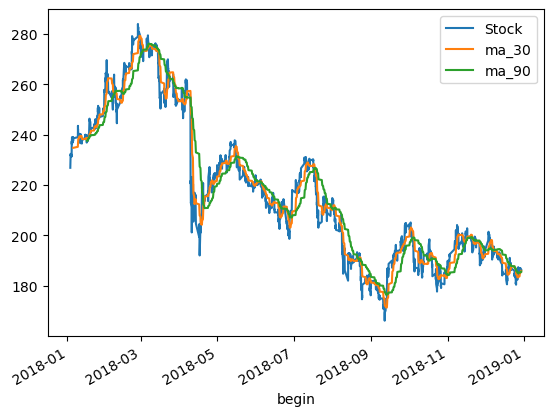

In [7]:
stock_close = stock['Close']
ma_30 = stock_close.rolling(fast_window).mean()
ma_90 = stock_close.rolling(slow_window).mean()
result = pd.concat([stock_close,ma_30,ma_90],axis=1)
result.columns = ['Stock','ma_30','ma_90']
result.plot();

# Часть 1 (скользящие фиксированы)

In [8]:
fast_ma = vbt.MA.run(stock_close, window=fast_window)
slow_ma = vbt.MA.run(stock_close, window=slow_window)
# Генерируем сигналы на покупку и продажу
dmac_entries = fast_ma.ma_crossed_above(slow_ma)
dmac_exits = fast_ma.ma_crossed_below(slow_ma)
out_dict = {}
exits = dmac_entries.vbt.signals.generate_ohlc_stop_exits(
    stock.get('Open'), 
    stock.get('High'), 
    stock.get('Low'), 
    stock.get('Close'),
    out_dict=out_dict,
    sl_stop=stop_loss
)
portfolio = vbt.Portfolio.from_signals(stock.get('Close'), dmac_entries, exits, freq='1H')

Создадим табличку с *правильными* сигналами на покупку и продажу, учитывая stop_loss

In [9]:
sig_buy = dmac_entries[dmac_entries == True].replace(True, 'buy')
sig_sell = dmac_exits[dmac_exits == True].replace(True, 'sell')
sig_stop = exits[exits == True].replace(True, 'stop')
signals = pd.concat([sig_buy, sig_sell, sig_stop]).sort_index()
if signals[0] == 'sell':
    signals[0] = np.nan
for i in range(len(signals) - 1):
    if signals[i] == 'stop' and signals[i+1] == 'sell':
        signals[i+1] = np.nan
    elif signals[i] == 'sell' and signals[i+1] == 'stop':
        signals[i+1] = np.nan   
signals = pd.DataFrame(signals).dropna()
signals.head(3)

,0
begin,
2018-02-14 15:00:00,buy
2018-03-02 17:00:00,sell
2018-03-23 13:00:00,buy


Выведем отчет по:
1. Прибыли
2. Сделкам

In [10]:
print(portfolio.stats())

Start                         2018-01-03 09:00:00
End                           2018-12-29 18:00:00
Period                          105 days 20:00:00
Start Value                                 100.0
End Value                               68.779884
Total Return [%]                       -31.220116
Benchmark Return [%]                   -17.886107
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        38.513137
Max Drawdown Duration            90 days 18:00:00
Total Trades                                   10
Total Closed Trades                             9
Total Open Trades                               1
Open Trade PnL                            0.58701
Win Rate [%]                            11.111111
Best Trade [%]                           2.096402
Worst Trade [%]                         -6.545663
Avg Winning Trade [%]                    2.096402
Avg Losing Trade [%]                    -4.908468


In [11]:
print(portfolio.orders.stats())

Start                2018-01-03 09:00:00
End                  2018-12-29 18:00:00
Period                 105 days 20:00:00
Total Records                         19
Total Buy Orders                      10
Total Sell Orders                      9
Min Size                        0.358118
Max Size                        0.411382
Avg Size                        0.377862
Avg Buy Size                    0.377428
Avg Sell Size                   0.378343
Avg Buy Price                    213.075
Avg Sell Price                206.917778
Total Fees                           0.0
Min Fees                             0.0
Max Fees                             0.0
Avg Fees                             0.0
Avg Buy Fees                         0.0
Avg Sell Fees                        0.0
dtype: object


Визуализируем наши данные

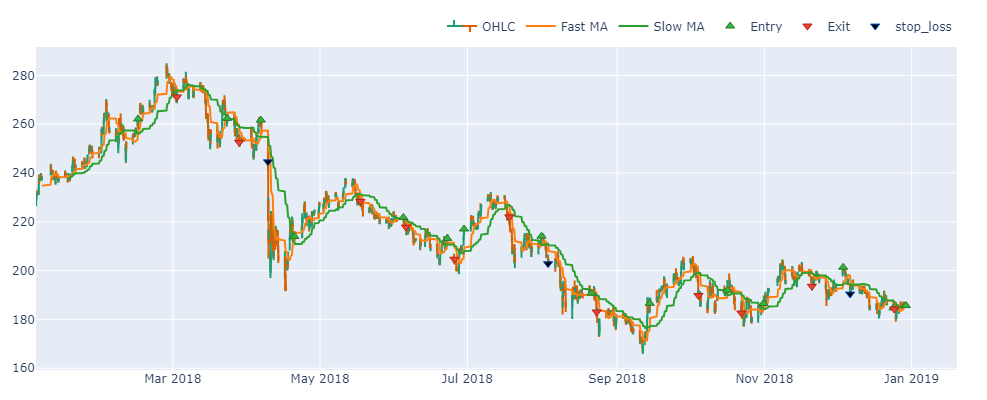

In [12]:
fig= stock.vbt.ohlcv.plot(width = 900, height = 400)
sl_price = portfolio.trades.records.exit_price[:-1]
sl_price.index = exits[exits == True].index
fig = fast_ma.ma.vbt.plot(trace_kwargs=dict(name='Fast MA'), fig=fig)
fig = slow_ma.ma.vbt.plot(trace_kwargs=dict(name='Slow MA'), fig=fig)
fig = dmac_entries.vbt.signals.plot_as_entry_markers(stock['Close'], fig=fig)
fig = dmac_exits.vbt.signals.plot_as_exit_markers(stock['Close'].loc[signals[(signals[0] == 'sell') == True].index], fig=fig)
fig = exits.vbt.signals.plot_as_markers(y = sl_price.loc[signals[(signals[0] == 'stop') == True].index], trace_kwargs=dict(marker=dict(symbol='triangle-down',color = 'black',size=8), name = 'stop_loss'), fig = fig)
fig.show()

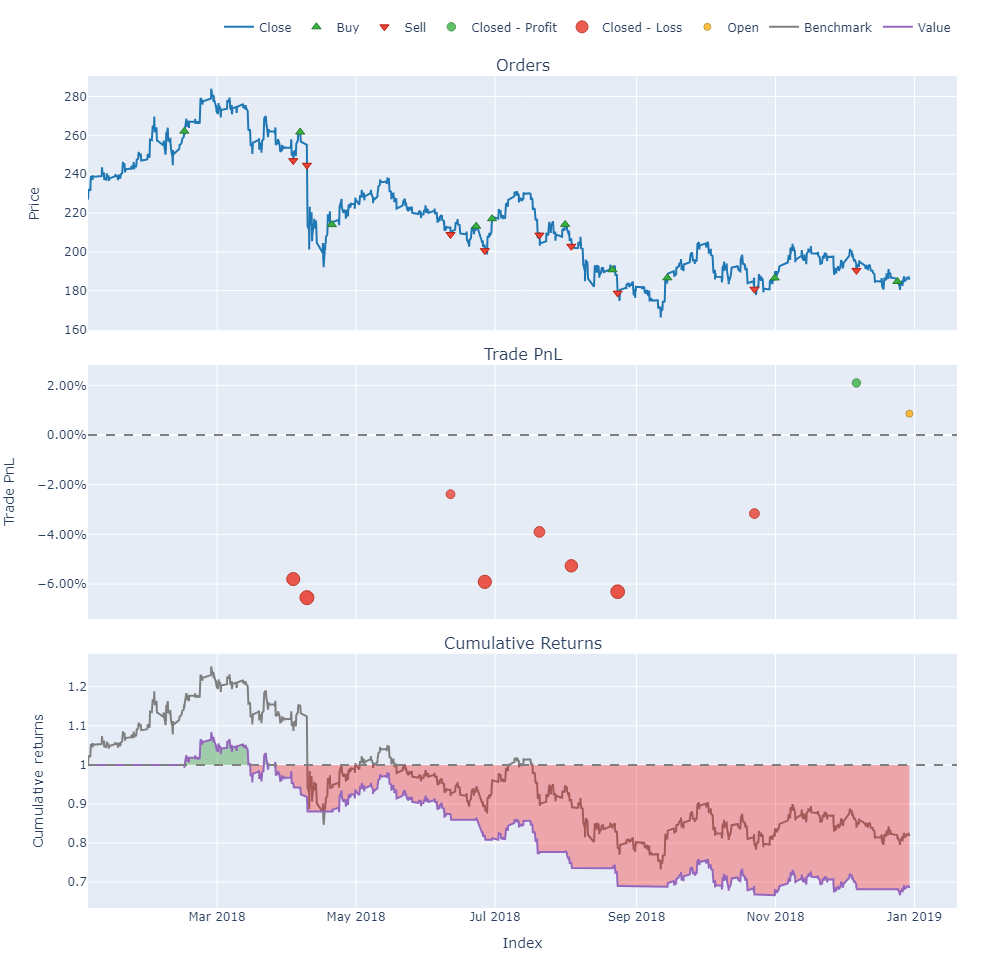

In [13]:
portfolio.plot().show() # Еще немного статистики

Посчитаем **прибыль** по сделкам и выведем информацию о торгах.
* Колонка *Close* - цена, по которой проводится текущая сделка
* Колонка *0* - обрабатываемый сигнал
* Колонка *Assets* - количество ценных бумаг после сделки (целое число)
* Колонка *Return* - объем средств на текущий момент

In [14]:
stock_return = stock[stock.index.isin(signals.index)]
stock_return = stock_return.merge(signals, on=signals.index)
stock_return.index = stock_return['key_0']
stock_return = stock_return [['Close', 0]]
assets = 0
trade_money = money
Assets = []
Return = []
for i in range(len(stock_return)):
    if stock_return[0].iloc[i] == 'buy':
        assets = trade_money // stock_return['Close'].iloc[i]
        Assets.append(assets)
        Return.append(trade_money % stock_return['Close'].iloc[i])
    elif stock_return[0].iloc[i] == 'sell' or stock_return[0].iloc[i] == 'stop':
        trade_money = assets*stock_return['Close'].iloc[i]
        Assets.append(0)
        Return.append(trade_money)
stock_return['Assets'] = np.array(Assets)
stock_return['Return'] = np.array(Return)
print('Прибыль:', round((trade_money - money)/money * 100, 2), '%')
display(stock_return)

Прибыль: -18.72 %


,Close,0,Assets,Return
key_0,,,,
2018-02-14 15:00:00,262.15,buy,381.0,120.85
2018-03-02 17:00:00,271.17,sell,0.0,103315.77
2018-03-23 13:00:00,262.38,buy,393.0,200.43
2018-03-28 12:00:00,252.59,sell,0.0,99267.87
2018-04-06 11:00:00,261.70,buy,379.0,83.57
2018-04-09 10:00:00,244.57,stop,0.0,92692.03
2018-04-20 09:00:00,214.00,buy,433.0,30.03
2018-05-17 17:00:00,228.37,sell,0.0,98884.21
2018-06-04 12:00:00,221.78,buy,445.0,192.11


# Часть 2 (максимизируем прибыль по скользящим)

Найдем максимальную прибыль при изменении скользящих. Построим тепловую карту, величины прибыли при разных значениях быстрой и медленной скользящих

 Быстрая скользящая: 2 
 Медленная скользящая: 14 
 Прибыль от сделок: 133.08 %


C:\Users\zvlad\anaconda3\Lib\site-packages\jupyter_client\session.py:718: UserWarning:

Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant



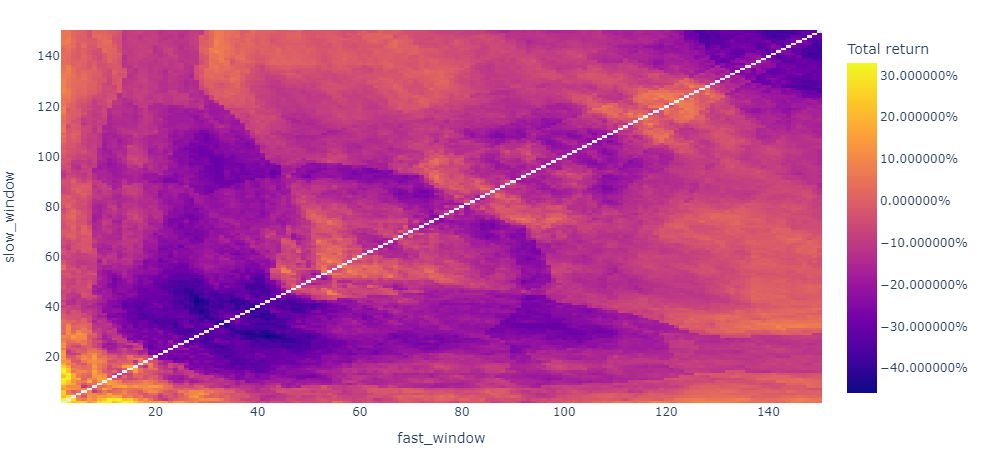

In [15]:
windows = np.arange(2, 151)
fast_ma, slow_ma = vbt.MA.run_combs(stock['Close'], window=windows, r=2, short_names=['fast', 'slow'])
entries = fast_ma.ma_crossed_above(slow_ma)
exits = fast_ma.ma_crossed_below(slow_ma)

pf_kwargs = dict(size=np.inf, freq='1H')
pf = vbt.Portfolio.from_signals(stock['Close'], entries, exits, **pf_kwargs)
max_ma = pf.total_return()[pf.total_return() == pf.total_return().max()].reset_index()
fast, slow, profit = int(max_ma.iloc[0][0]), int(max_ma.iloc[0][1]), max_ma.iloc[0][2]

print('','Быстрая скользящая:', fast, '\n', 'Медленная скользящая:', slow, '\n', 'Прибыль от сделок:', np.round(100 + profit*100, 2), '%')

fig = pf.total_return().vbt.heatmap(
    x_level='fast_window', y_level='slow_window',  symmetric=True,
    trace_kwargs=dict(colorbar=dict(title='Total return', tickformat='%')))
fig.show()

In [16]:
fast_ma = vbt.MA.run(stock_close, window=fast)
slow_ma = vbt.MA.run(stock_close, window=slow)
# Генерируем сигналы на покупку и продажу
dmac_entries = fast_ma.ma_crossed_above(slow_ma)
dmac_exits = fast_ma.ma_crossed_below(slow_ma)
out_dict = {}
exits = dmac_entries.vbt.signals.generate_ohlc_stop_exits(
    stock.get('Open'), 
    stock.get('High'), 
    stock.get('Low'), 
    stock.get('Close'),
    out_dict=out_dict,
    sl_stop=stop_loss
)
portfolio = vbt.Portfolio.from_signals(stock.get('Close'), dmac_entries, exits, freq='1H')

Создадим табличку с *правильными* сигналами на покупку и продажу, учитывая stop_loss

In [17]:
sig_buy = dmac_entries[dmac_entries == True].replace(True, 'buy')
sig_sell = dmac_exits[dmac_exits == True].replace(True, 'sell')
sig_stop = exits[exits == True].replace(True, 'stop')
signals = pd.concat([sig_buy, sig_sell, sig_stop]).sort_index()
if signals[0] == 'sell':
    signals[0] = np.nan
for i in range(len(signals) - 1):
    if signals[i] == 'stop' and signals[i+1] == 'sell':
        signals[i+1] = np.nan
    elif signals[i] == 'sell' and signals[i+1] == 'stop':
        signals[i+1] = np.nan   
signals = pd.DataFrame(signals).dropna()

Выведем отчет по:
1. Прибыли
2. Сделкам

In [18]:
print(portfolio.stats())

Start                         2018-01-03 09:00:00
End                           2018-12-29 18:00:00
Period                          105 days 20:00:00
Start Value                                 100.0
End Value                                77.08126
Total Return [%]                        -22.91874
Benchmark Return [%]                   -17.886107
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        38.043249
Max Drawdown Duration            90 days 18:00:00
Total Trades                                   13
Total Closed Trades                            12
Total Open Trades                               1
Open Trade PnL                          -0.620622
Win Rate [%]                            33.333333
Best Trade [%]                          12.044653
Worst Trade [%]                        -14.050875
Avg Winning Trade [%]                    6.101797
Avg Losing Trade [%]                    -5.818496


In [19]:
print(portfolio.orders.stats())

Start                2018-01-03 09:00:00
End                  2018-12-29 18:00:00
Period                 105 days 20:00:00
Total Records                         25
Total Buy Orders                      13
Total Sell Orders                     12
Min Size                        0.406159
Max Size                        0.422462
Avg Size                         0.41622
Avg Buy Size                    0.416125
Avg Sell Size                   0.416323
Avg Buy Price                 206.972308
Avg Sell Price                  204.1425
Total Fees                           0.0
Min Fees                             0.0
Max Fees                             0.0
Avg Fees                             0.0
Avg Buy Fees                         0.0
Avg Sell Fees                        0.0
dtype: object


Визуализируем наши данные

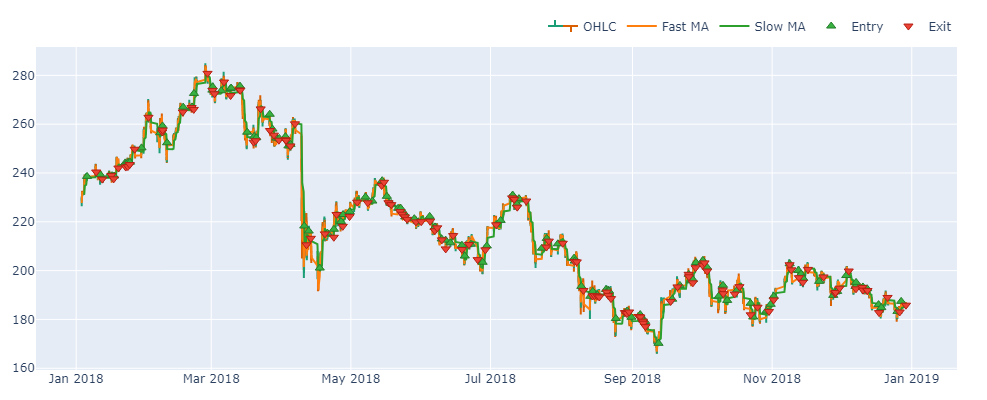

In [20]:
fig= stock.vbt.ohlcv.plot(width = 900, height = 400)
sl_price = portfolio.trades.records.exit_price[:-1]
sl_price.index = exits[exits == True].index
fig = fast_ma.ma.vbt.plot(trace_kwargs=dict(name='Fast MA'), fig=fig)
fig = slow_ma.ma.vbt.plot(trace_kwargs=dict(name='Slow MA'), fig=fig)
fig = dmac_entries.vbt.signals.plot_as_entry_markers(stock['Close'], fig=fig)
fig = dmac_exits.vbt.signals.plot_as_exit_markers(stock['Close'].loc[signals[(signals[0] == 'sell') == True].index], fig=fig)
fig = exits.vbt.signals.plot_as_markers(y = sl_price.loc[signals[(signals[0] == 'stop') == True].index], trace_kwargs=dict(marker=dict(symbol='triangle-down',color = 'black',size=8), name = 'stop_loss'), fig = fig)
fig.show()

Посчитаем **прибыль** по сделкам и выведем информацию о торгах.
* Колонка *Close* - цена, по которой проводится текущая сделка
* Колонка *0* - обрабатываемый сигнал
* Колонка *Assets* - количество ценных бумаг после сделки (целое число)
* Колонка *Return* - объем средств на текущий момент

In [21]:
stock_return = stock[stock.index.isin(signals.index)]
stock_return = stock_return.merge(signals, on=signals.index)
stock_return.index = stock_return['key_0']
stock_return = stock_return [['Close', 0]]
assets = 0
trade_money = money
Assets = []
Return = []
for i in range(len(stock_return)):
    if stock_return[0].iloc[i] == 'buy':
        assets = trade_money // stock_return['Close'].iloc[i]
        Assets.append(assets)
        Return.append(trade_money % stock_return['Close'].iloc[i])
    elif stock_return[0].iloc[i] == 'sell' or stock_return[0].iloc[i] == 'stop':
        trade_money = assets*stock_return['Close'].iloc[i]
        Assets.append(0)
        Return.append(trade_money)
stock_return['Assets'] = np.array(Assets)
stock_return['Return'] = np.array(Return)
print('Прибыль:', round((trade_money - money)/money * 100, 2), '%')
display(stock_return)

Прибыль: 18.38 %


,Close,0,Assets,Return
key_0,,,,
2018-01-05 18:00:00,238.60,buy,419.0,26.60
2018-01-09 18:00:00,240.40,sell,0.0,100727.60
2018-01-11 12:00:00,239.41,buy,420.0,175.40
2018-01-12 10:00:00,237.48,sell,0.0,99741.60
2018-01-15 09:00:00,239.00,buy,417.0,78.60
...,...,...,...,...
2018-12-21 10:00:00,189.01,sell,0.0,119832.34
2018-12-25 18:00:00,183.30,buy,653.0,137.44
2018-12-26 17:00:00,183.04,sell,0.0,119525.12
